In [ ]:
from google.colab import files

uploaded=files.upload()

In [ ]:
import zipfile
import re

zip_file_name="Flower Images Dataset.zip"

extract_folder="/content/Flower_Dataset"

with zipfile.ZipFile(zip_file_name,'r') as zip_ref:
  zip_ref.extractall(extract_folder)

print("Dataset extracted successfully.")


Dataset extracted successfully.


In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
image_size=(128,128)
batch_size=32

#Augmentation
train_datagen=ImageDataGenerator(
    rescale=1./255,  #normalizing pixel values to [0, 1]
    rotation_range=20,  #randomly rotate images
    zoom_range=0.2,  #randomly zoom images
    shear_range=0.2,  #randomly shear images
    horizontal_flip=True,  #randomly flip images horizontally
    validation_split=0.2  #split data into training and validation sets
    #it is optional only when no validation data is provided
)


In [ ]:
train_generator=train_datagen.flow_from_directory(
'/content/Flower_Dataset/flower_images',  #directory containing the dataset
target_size=image_size,  #resizing images to 128*128
class_mode='categorical',  #number of images to process in each batch
batch_size=batch_size,   #number of images to process in each batch
subset='training'  #indicating this is the training set
)

#validation data
val_generator=train_datagen.flow_from_directory(
'/content/Flower_Dataset/flower_images',
target_size=image_size,
class_mode='categorical',
batch_size=batch_size,
subset='validation',
shuffle=False  #do not shuffle validation data
)


Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


In [ ]:
#Map class indices to class names
class_indices=train_generator.class_indices
class_names=list(class_indices.keys())
print(class_indices)
print("classes:",class_names)
print("no of classes:",len(class_names))

{'Lilly': 0, 'Lotus': 1, 'Orchid': 2, 'Sunflower': 3, 'Tulip': 4}
classes: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']
no of classes: 5


In [ ]:
# GET ONE BATCH

images, labels=next(train_generator)

print(labels)


[[0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


In [ ]:
#DISPLAY BATCH SHAPE

print("Image Batch Shape:",images.shape)

print("Label Batch Shape:",labels.shape)

#32=batch size,128=image height,128=image width,3=RGB channels,6=number of classes

Image Batch Shape: (32, 128, 128, 3)
Label Batch Shape: (32, 5)


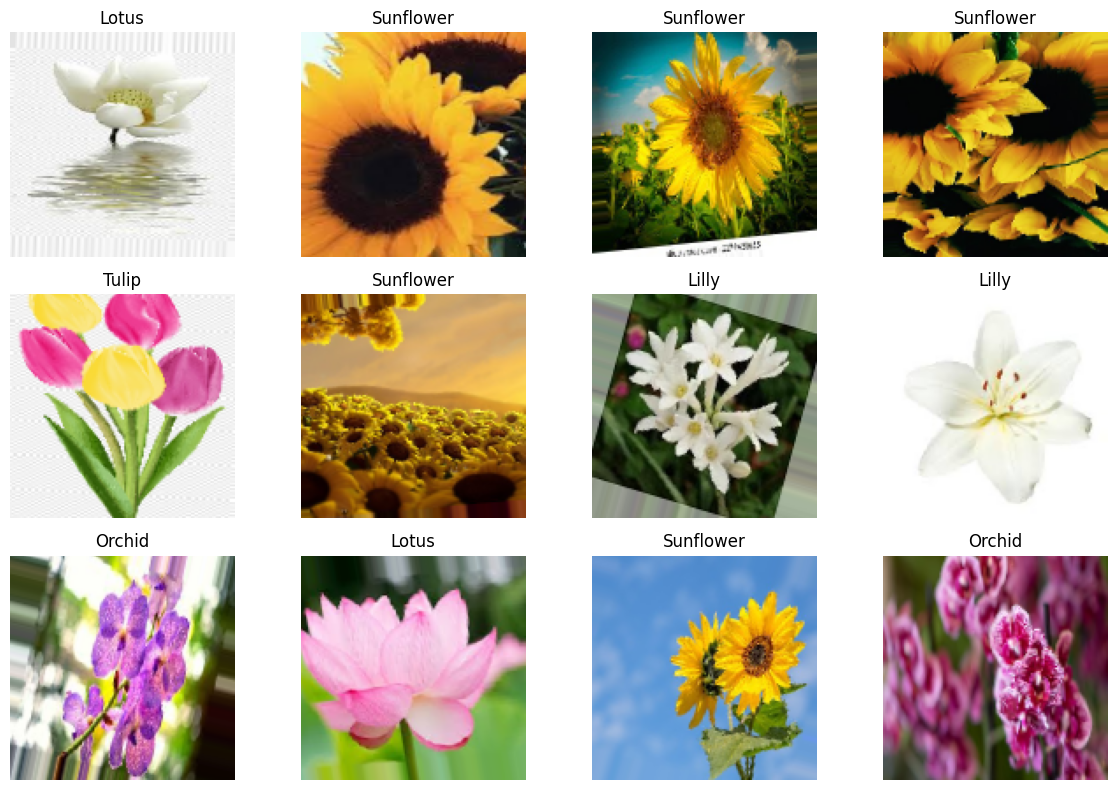

In [ ]:
#DISPLAY SAMPLE IMAGES WITH LABELS

plt.figure(figsize=(12,8))
for i in range(12):
  plt.subplot(3,4,i+1)
  plt.imshow(images[i])
  plt.title(class_names[np.argmax(labels[i])])
  plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#COMPUTE CLASS WEIGHTS

from sklearn.utils.class_weight import compute_class_weight

class_weights=compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict=dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [ ]:
#CREATE EARLY STOPPING CALLBACK

from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
#IMPORT MLP SPECIFIC LIBRARIES

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
#BUILD MLP MODEL

mlp_model=Sequential([
    Flatten(input_shape=(128,128,3)),
    Dense(128,activation='relu'),
    Dropout(0.4),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(len(class_names),activation='softmax')
])
mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,308,741 (24.07 MB)

 Trainable params: 6,308,741 (24.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#COMPILE MLP MODEL

mlp_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("MLP Model Compiled Successfully")

MLP Model Compiled Successfully


In [ ]:
#TRAIN MLP MODEL

history=mlp_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 374ms/step - accuracy: 0.2905 - loss: 1.6901 - val_accuracy: 0.3400 - val_loss: 1.5210
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 371ms/step - accuracy: 0.2920 - loss: 1.5325 - val_accuracy: 0.3660 - val_loss: 1.5167
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 351ms/step - accuracy: 0.3235 - loss: 1.5046 - val_accuracy: 0.3520 - val_loss: 1.4519
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 361ms/step - accuracy: 0.3165 - loss: 1.4881 - val_accuracy: 0.3740 - val_loss: 1.4343
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 355ms/step - accuracy: 0.3235 - loss: 1.4808 - val_accuracy: 0.3750 - val_loss: 1.4453
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 362ms/step - accuracy: 0.3352 - loss: 1.4616 - val_accuracy: 0.3810 - val_loss: 1.3863
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 353ms/step - accuracy: 0.3370 - loss: 1.4689 - val_accuracy: 0.3910 - val_loss: 1.4197
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 363ms/step - accuracy: 0.3545 - loss: 1

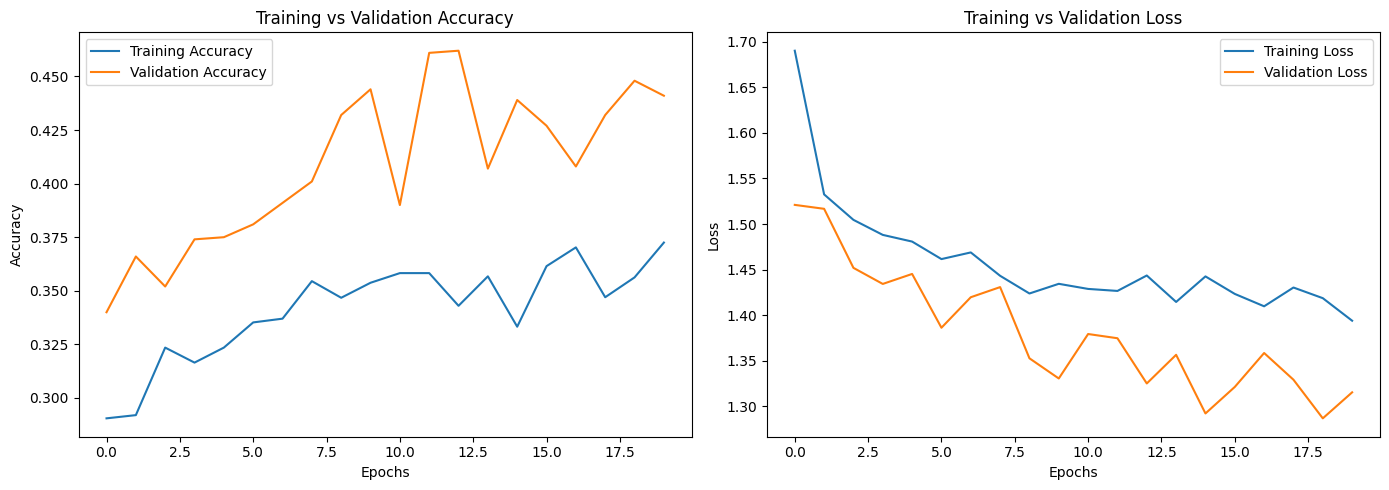

In [ ]:
#PLOT TRAINING AND VALIDATION CURVES

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy')
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#loss

plt.subplot(1,2,2)
plt.plot(
    history.history['loss'],
    label='Training Loss')
plt.plot(
    history.history['val_loss'],
    label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#EVALUATE MLP MODEL

loss,accuracy=mlp_model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 0.4560 - loss: 1.2902
Validation Loss: 1.2902
Validation Accuracy: 0.4560


In [ ]:
#GENERATE PREDICTIONS

y_pred=mlp_model.predict(val_generator)
y_pred=np.argmax(y_pred,axis=1)
y_true=val_generator.classes


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step


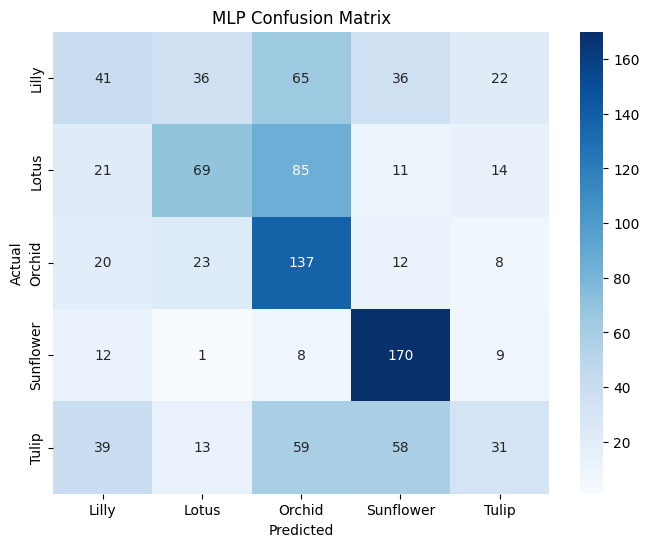

In [ ]:
#CONFUSION MATRIX

cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("MLP Confusion Matrix")
plt.show()

In [ ]:
#CLASSIFICATION REPORT

print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

       Lilly       0.31      0.20      0.25       200
       Lotus       0.49      0.34      0.40       200
      Orchid       0.39      0.69      0.49       200
   Sunflower       0.59      0.85      0.70       200
       Tulip       0.37      0.15      0.22       200

    accuracy                           0.45      1000
   macro avg       0.43      0.45      0.41      1000
weighted avg       0.43      0.45      0.41      1000



In [ ]:
#SAVE MLP MODEL

mlp_model.save('Flower_MLP_model.keras')
print("MLP Model Saved Successfully")

MLP Model Saved Successfully


In [ ]:
#BUILD CNN MODEL

cnn_model=Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(pool_size=(2,2)),

        Flatten(),

        Dense(128,activation='relu'),
        Dropout(0.5),

        Dense(len(class_names),activation='softmax')
])
print(cnn_model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#COMPILE CNN MODEL

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(" CNN Model Compiled Successfully")


 CNN Model Compiled Successfully


In [ ]:
#TRAIN CNN MODEL

history=cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)

NameError: name 'cnn_model' is not defined

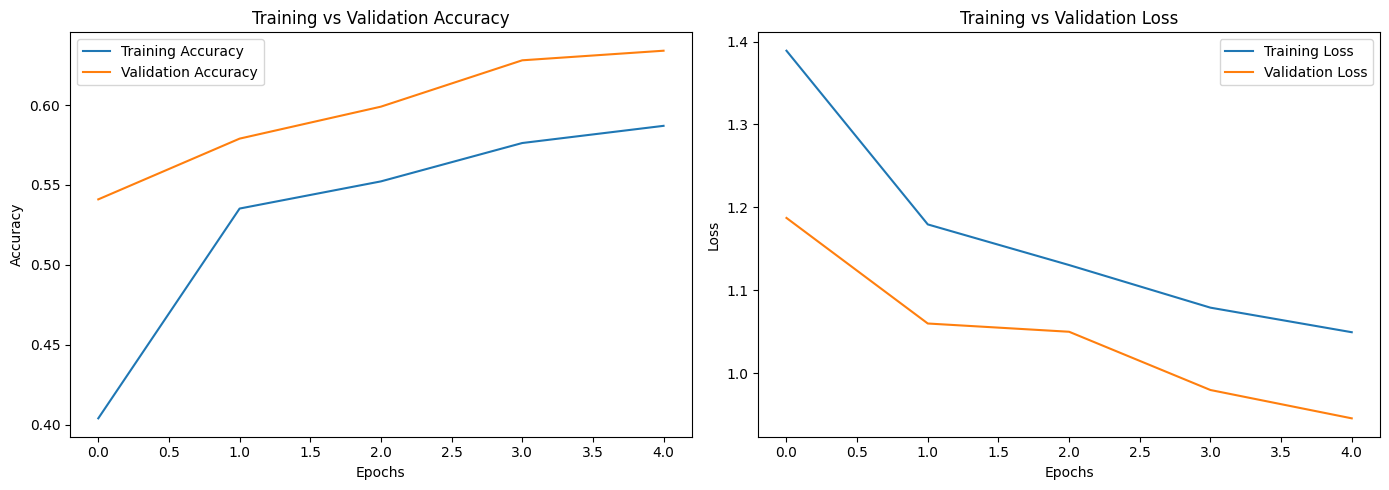

In [ ]:
#PLOT TRAINING AND VALIDATION CURVES

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy')
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#loss

plt.subplot(1,2,2)
plt.plot(
    history.history['loss'],
    label='Training Loss')
plt.plot(
    history.history['val_loss'],
    label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#EVALUATE CNN MODEL

loss,accuracy=cnn_model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - accuracy: 0.5360 - loss: 1.1875
Validation Loss: 1.1875
Validation Accuracy: 0.5360


In [ ]:
#GENERATE PREDICTIONS

y_pred=cnn_model.predict(val_generator)
y_pred=np.argmax(y_pred,axis=1)
y_true=val_generator.classes


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step


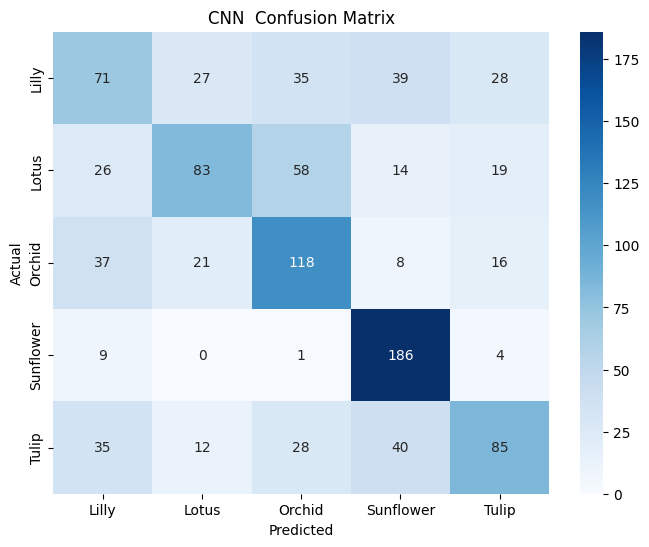

In [ ]:
#CONFUSION MATRIX

cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("CNN  Confusion Matrix")
plt.show()

In [ ]:
#CLASSIFICATION REPORT

print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

       Lilly       0.40      0.35      0.38       200
       Lotus       0.58      0.41      0.48       200
      Orchid       0.49      0.59      0.54       200
   Sunflower       0.65      0.93      0.76       200
       Tulip       0.56      0.42      0.48       200

    accuracy                           0.54      1000
   macro avg       0.54      0.54      0.53      1000
weighted avg       0.54      0.54      0.53      1000



In [ ]:
#SAVE CNN MODEL

cnn_model.save('Flower_CNN_model.keras')
print("CNN Model Saved Successfully")

CNN Model Saved Successfully


In [ ]:
#Transfer learning---using pretrained models----mobilenet, resnet, efficientnet,vgg16
#IMPORT MobileNet V2 LIBRARIES

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D,Dense,Dropout)
from tensorflow.keras.optimizers import Adam

In [ ]:
#BUILD MOBILE NET V2 BASE MODEL

base_model=MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_1.00_128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
# FREEEZE PRETRAINED LAYERS

base_model.trainable=False

print("Base Model Frozen")

Base Model Frozen


In [ ]:
#ADD CUSTOM CLASSIFICATION LAYERS

x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(256,activation='relu')(x)
x=Dropout(0.5)(x)
output=Dense(len(class_names),activation='softmax')(x)

mobilenet_model=Model(
    inputs=base_model.input,
    outputs=output
)
mobilenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# COMPLIE MOBILE NET V2 MODEL

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("MobileNetV2 Model Compiled")

MobileNetV2 Model Compiled


In [ ]:
# TRAIN MOBILE NET V2 (STAGE 1)

history=mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 379ms/step - accuracy: 0.4585 - loss: 1.3884 - val_accuracy: 0.7200 - val_loss: 0.7771
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 242ms/step - accuracy: 0.6637 - loss: 0.8708 - val_accuracy: 0.7780 - val_loss: 0.6189
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 249ms/step - accuracy: 0.7440 - loss: 0.6943 - val_accuracy: 0.8210 - val_loss: 0.5553
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 246ms/step - accuracy: 0.7632 - loss: 0.6391 - val_accuracy: 0.8320 - val_loss: 0.5011
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 248ms/step - accuracy: 0.7920 - loss: 0.5748 - val_accuracy: 0.8310 - val_loss: 0.4753
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 243ms/step - accuracy: 0.7997 - loss: 0.5383 - val_accuracy: 0.8500 - val_loss: 0.4467
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 250ms/step - accuracy: 0.8227 - loss: 0.4925 - val_accuracy: 0.8560 - val_loss: 0.4396
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 271ms/step - accuracy: 0.8315 - loss: 0

In [ ]:
# FINE TUNE MOBILE NET V2

base_model.trainable=True
for layer in base_model.layers[:-20]:
  layer.trainable=False

print("Fine Tuning Enabled")

Fine Tuning Enabled


In [ ]:
# RECOMPILE AFTER FINE TUNING

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# TRAIN MOBILE NET V2 (STAGE 2)

history_finetune=mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 54s 318ms/step - accuracy: 0.7893 - loss: 0.5797 - val_accuracy: 0.8740 - val_loss: 0.3363
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 246ms/step - accuracy: 0.8242 - loss: 0.4868 - val_accuracy: 0.8830 - val_loss: 0.3326
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 251ms/step - accuracy: 0.8455 - loss: 0.4278 - val_accuracy: 0.8860 - val_loss: 0.3437
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 249ms/step - accuracy: 0.8500 - loss: 0.3982 - val_accuracy: 0.8910 - val_loss: 0.3133
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 253ms/step - accuracy: 0.8533 - loss: 0.3988 - val_accuracy: 0.8890 - val_loss: 0.3280
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 245ms/step - accuracy: 0.8660 - loss: 0.3612 - val_accuracy: 0.8880 - val_loss: 0.3362
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 283ms/step - accuracy: 0.8817 - loss: 0.3284 - val_accuracy: 0.8880 - val_loss: 0.3084
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 286ms/step - accuracy: 0.8890 - loss: 0

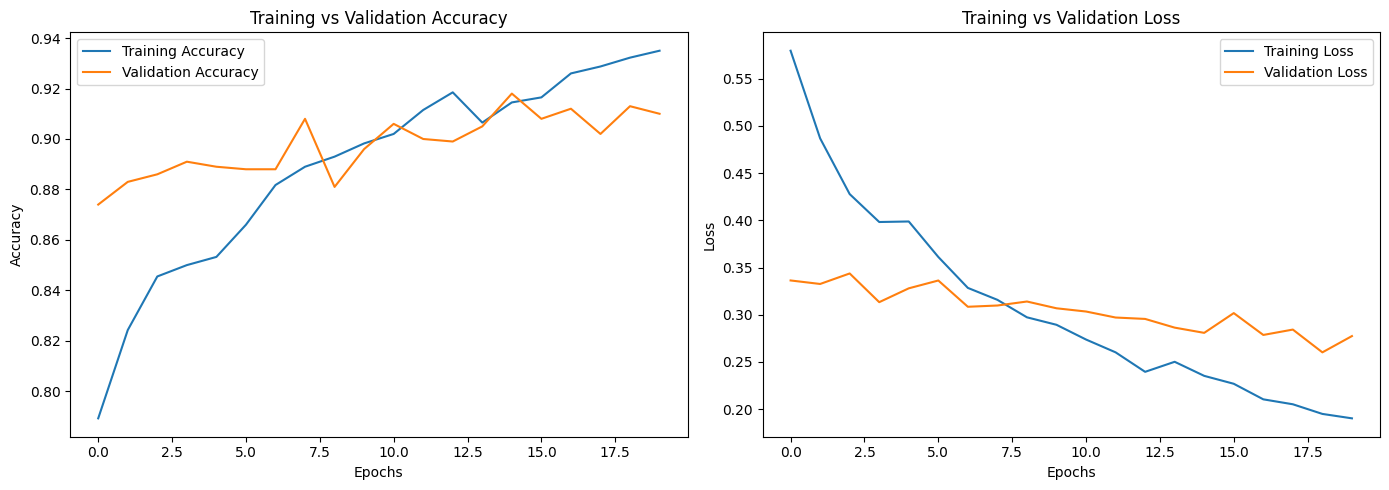

In [ ]:
# PLOT TRAINING AND VALIDATION CURVES

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(
    history_finetune.history['accuracy'],
    label='Training Accuracy')
plt.plot(
    history_finetune.history['val_accuracy'],
    label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#loss

plt.subplot(1,2,2)
plt.plot(
    history_finetune.history['loss'],
    label='Training Loss')
plt.plot(
    history_finetune.history['val_loss'],
    label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# EVALUATE MOBILE NET

loss,accuracy=mobilenet_model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.9100 - loss: 0.2932
Validation Loss: 0.2932
Validation Accuracy: 0.9100


In [ ]:
# GENERATE PREDICTIONS

y_pred=mobilenet_model.predict(val_generator)
y_pred=np.argmax(y_pred,axis=1)
y_true=val_generator.classes


32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 339ms/step


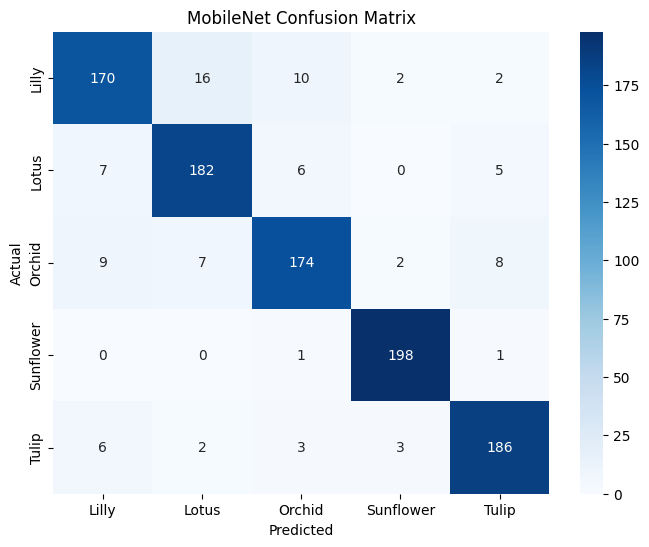

In [ ]:
#CONFUSION MATRIX

cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("MobileNet Confusion Matrix")
plt.show()

In [ ]:
#CLASSIFICATION REPORT

print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

       Lilly       0.89      0.85      0.87       200
       Lotus       0.88      0.91      0.89       200
      Orchid       0.90      0.87      0.88       200
   Sunflower       0.97      0.99      0.98       200
       Tulip       0.92      0.93      0.93       200

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



In [ ]:
#SAVE MOBILENET MODEL

mobilenet_model.save('Flower_MobileNetV2_model.keras')
print("MobileNet V2 Model Saved Successfully")

MobileNet V2 Model Saved Successfully


In [ ]:
# IMPORT LIBRARIES FOR RESNET

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# BUILD RESNET BASE MODEL

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
# FREEZE PRETRAINED LAYERS

base_model.trainable = False

print("Base Model Frozen")

Base Model Frozen


In [ ]:
# ADD CUSTOM CLASSIFICATION LAYERS

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(class_names), activation='softmax')(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=output
)

resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# COMPILE RESNET MODEL

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("ResNet50 Model Compiled")

ResNet50 Model Compiled


In [ ]:
# TRAIN RESNET (STAGE 1)

history = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 326ms/step - accuracy: 0.1955 - loss: 1.7401 - val_accuracy: 0.2340 - val_loss: 1.5965
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 265ms/step - accuracy: 0.2148 - loss: 1.6640 - val_accuracy: 0.2930 - val_loss: 1.5832
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 256ms/step - accuracy: 0.2198 - loss: 1.6288 - val_accuracy: 0.3670 - val_loss: 1.5693
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 263ms/step - accuracy: 0.2438 - loss: 1.5979 - val_accuracy: 0.3170 - val_loss: 1.5605
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 262ms/step - accuracy: 0.2652 - loss: 1.5818 - val_accuracy: 0.3350 - val_loss: 1.5572


In [ ]:
# FINE TUNE RESNET

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Fine Tuning Enabled")

Fine Tuning Enabled


In [ ]:
# RECOMPILE AFTER FINE TUNING

resnet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("ResNet50 Recompiled Successfully")

ResNet50 Recompiled Successfully


In [ ]:
# TRAIN RESNET (STAGE 2)

history_finetune = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 317ms/step - accuracy: 0.2808 - loss: 1.5869 - val_accuracy: 0.2500 - val_loss: 1.6225
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 262ms/step - accuracy: 0.3877 - loss: 1.4426 - val_accuracy: 0.2740 - val_loss: 1.5885
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 265ms/step - accuracy: 0.4205 - loss: 1.3814 - val_accuracy: 0.4160 - val_loss: 1.4825
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 269ms/step - accuracy: 0.4690 - loss: 1.2914 - val_accuracy: 0.5020 - val_loss: 1.2696
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 269ms/step - accuracy: 0.5095 - loss: 1.2330 - val_accuracy: 0.5460 - val_loss: 1.1683


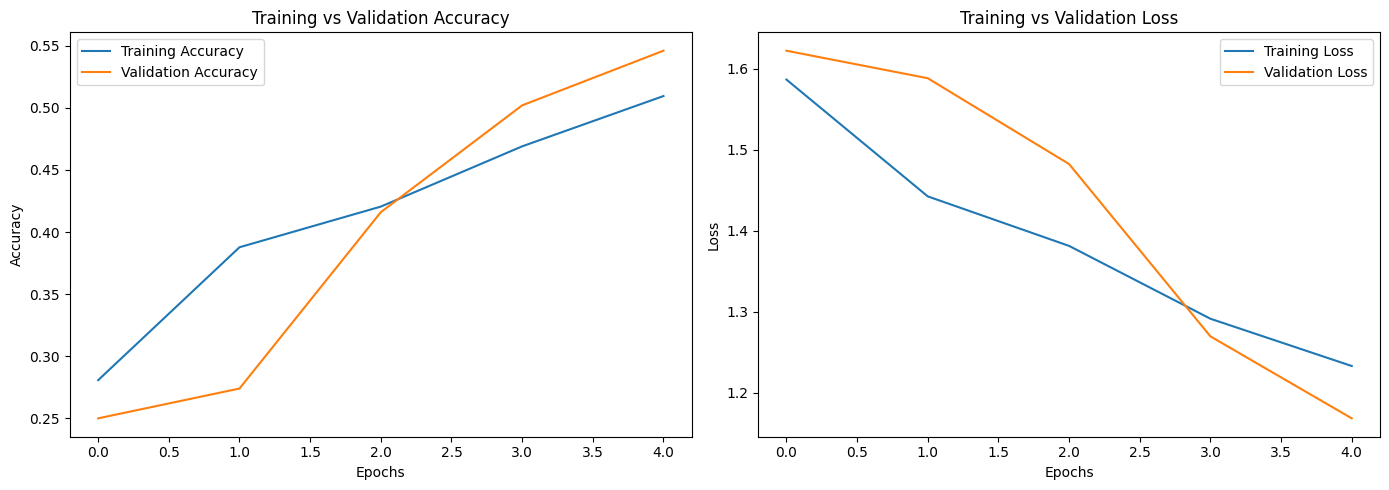

In [ ]:
# PLOT TRAINING AND VALIDATION CURVES

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(
    history_finetune.history['accuracy'],
    label='Training Accuracy')
plt.plot(
    history_finetune.history['val_accuracy'],
    label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(
    history_finetune.history['loss'],
    label='Training Loss')
plt.plot(
    history_finetune.history['val_loss'],
    label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# EVALUATE RESNET

loss, accuracy = resnet_model.evaluate(val_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 0.2600 - loss: 1.6188
Validation Loss: 1.6188
Validation Accuracy: 0.2600


In [ ]:
# GENERATE PREDICTIONS

y_pred = resnet_model.predict(val_generator)
y_pred = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step


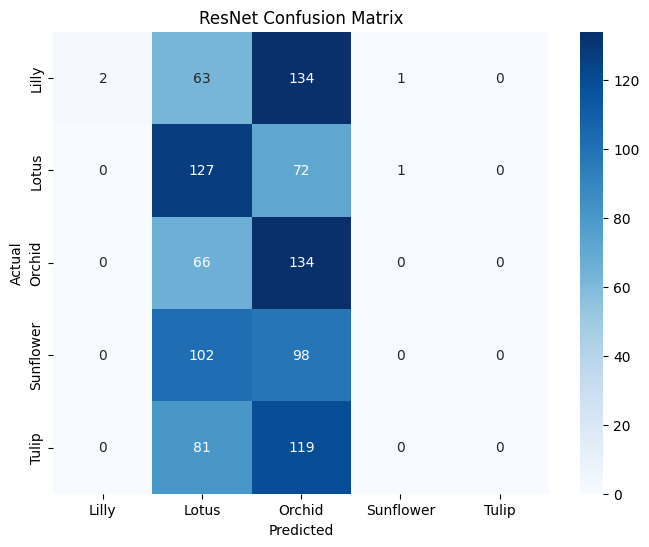

In [ ]:
#CONFUSION MATRIX

cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("ResNet Confusion Matrix")
plt.show()

In [ ]:
#CLASSIFICATION REPORT

print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

       Lilly       1.00      0.01      0.02       200
       Lotus       0.29      0.64      0.40       200
      Orchid       0.24      0.67      0.35       200
   Sunflower       0.00      0.00      0.00       200
       Tulip       0.00      0.00      0.00       200

    accuracy                           0.26      1000
   macro avg       0.31      0.26      0.15      1000
weighted avg       0.31      0.26      0.15      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#SAVE RESNET MODEL

mobilenet_model.save('Flower_ResNet_model.keras')
print("ResNet Model Saved Successfully")

ResNet Model Saved Successfully


In [ ]:
# IMPORT LIBRARIES FOR EfficientNet libraries

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# BUILD EfficientNet BASE MODEL

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [ ]:
# FREEZE PRETRAINED LAYERS

base_model.trainable = False

print("Base Model Frozen")

Base Model Frozen


In [ ]:
# ADD CUSTOM CLASSIFICATION LAYERS

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(class_names), activation='softmax')(x)

efficientnet_model = Model(
    inputs=base_model.input,
    outputs=output
)

efficientnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │        512 │ block1a_se_excit

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# COMPILE EfficientNet MODEL

efficientnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("EfficientNetB0 Model Compiled")

EfficientNetB0 Model Compiled


In [ ]:
# TRAIN EfficientNet (STAGE 1)

history = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 375ms/step - accuracy: 0.1915 - loss: 1.6385 - val_accuracy: 0.2040 - val_loss: 1.6120
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 285ms/step - accuracy: 0.1957 - loss: 1.6197 - val_accuracy: 0.2000 - val_loss: 1.6094
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 245ms/step - accuracy: 0.1985 - loss: 1.6157 - val_accuracy: 0.2000 - val_loss: 1.6103
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 251ms/step - accuracy: 0.1933 - loss: 1.6144 - val_accuracy: 0.2000 - val_loss: 1.6101
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 243ms/step - accuracy: 0.1940 - loss: 1.6117 - val_accuracy: 0.2000 - val_loss: 1.6098


In [ ]:
# FINE TUNE EfficientNet

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Fine Tuning Enabled")

Fine Tuning Enabled


In [ ]:
# RECOMPILE EfficientNet AFTER FINE TUNING

efficientnet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("EfficientNetB0 Recompiled Successfully")

EfficientNetB0 Recompiled Successfully


In [ ]:
# TRAIN EfficientNetB0 (STAGE 2)

history_finetune = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 252ms/step - accuracy: 0.2062 - loss: 1.6350 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 251ms/step - accuracy: 0.2070 - loss: 1.6316 - val_accuracy: 0.2000 - val_loss: 1.6065
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 253ms/step - accuracy: 0.2103 - loss: 1.6287 - val_accuracy: 0.2000 - val_loss: 1.6053
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 247ms/step - accuracy: 0.2167 - loss: 1.6193 - val_accuracy: 0.2000 - val_loss: 1.6042
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 285ms/step - accuracy: 0.2072 - loss: 1.6238 - val_accuracy: 0.2200 - val_loss: 1.6023


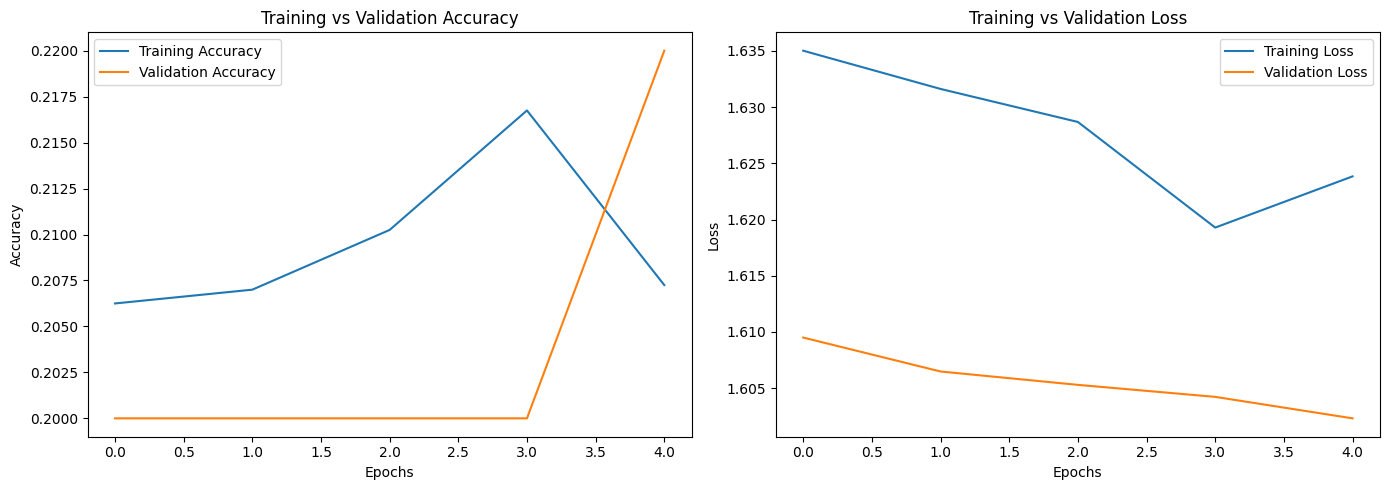

In [ ]:
# PLOT TRAINING AND VALIDATION CURVES

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(
    history_finetune.history['accuracy'],
    label='Training Accuracy')
plt.plot(
    history_finetune.history['val_accuracy'],
    label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#loss

plt.subplot(1,2,2)
plt.plot(
    history_finetune.history['loss'],
    label='Training Loss')
plt.plot(
    history_finetune.history['val_loss'],
    label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# EVALUATE EfficientNet

loss, accuracy = efficientnet_model.evaluate(val_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.2000 - loss: 1.6094
Validation Loss: 1.6094
Validation Accuracy: 0.2000


In [ ]:
# GENERATE PREDICTIONS

y_pred =efficientnet_model.predict(val_generator)
y_pred = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 421ms/step


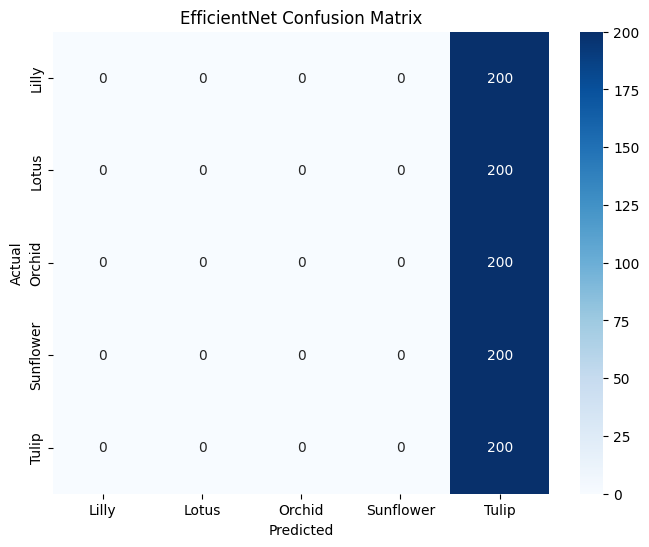

In [ ]:
#CONFUSION MATRIX

cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("EfficientNet Confusion Matrix")
plt.show()

In [ ]:
#CLASSIFICATION REPORT

print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

       Lilly       0.00      0.00      0.00       200
       Lotus       0.00      0.00      0.00       200
      Orchid       0.00      0.00      0.00       200
   Sunflower       0.00      0.00      0.00       200
       Tulip       0.20      1.00      0.33       200

    accuracy                           0.20      1000
   macro avg       0.04      0.20      0.07      1000
weighted avg       0.04      0.20      0.07      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#SAVE EfficientNet MODEL

mobilenet_model.save('Flower_EfficientNet_model.keras')
print("EfficientNet Model Saved Successfully")

EfficientNet Model Saved Successfully


In [ ]:
# IMPORT LIBRARIES FOR VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
#BUILD VGG16 BASE MODEL

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# FREEZE PRETRAINED LAYERS

base_model.trainable = False

print("Base Model Frozen")

Base Model Frozen


In [ ]:
#ADD CUSTOM CLASSIFICATION LAYERS

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(class_names), activation='softmax')(x)

vgg16_model = Model(
    inputs=base_model.input,
    outputs=output
)

vgg16_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# COMPILE VGG16 MODEL

vgg16_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("VGG16 Model Compiled")

VGG16 Model Compiled


In [ ]:
# TRAIN VGG16 (STAGE 1)

history = vgg16_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 306ms/step - accuracy: 0.2508 - loss: 1.6713 - val_accuracy: 0.5030 - val_loss: 1.4488
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 271ms/step - accuracy: 0.3625 - loss: 1.4757 - val_accuracy: 0.5500 - val_loss: 1.3244
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 278ms/step - accuracy: 0.4630 - loss: 1.3398 - val_accuracy: 0.6160 - val_loss: 1.2093
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - accuracy: 0.5385 - loss: 1.2379 - val_accuracy: 0.6590 - val_loss: 1.1277
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 279ms/step - accuracy: 0.5675 - loss: 1.1620 - val_accuracy: 0.6650 - val_loss: 1.0599


In [ ]:
# FINE TUNE VGG16

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Fine Tuning Enabled")


Fine Tuning Enabled


In [ ]:
# RECOMPILE AFTER FINE TUNING

vgg16_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# TRAIN VGG16 (STAGE 2)

history_finetune = vgg16_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 70s 328ms/step - accuracy: 0.6118 - loss: 1.0000 - val_accuracy: 0.8050 - val_loss: 0.5782
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 316ms/step - accuracy: 0.7847 - loss: 0.5953 - val_accuracy: 0.8630 - val_loss: 0.3964
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 314ms/step - accuracy: 0.8425 - loss: 0.4325 - val_accuracy: 0.8700 - val_loss: 0.3725
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 309ms/step - accuracy: 0.8687 - loss: 0.3754 - val_accuracy: 0.8870 - val_loss: 0.3119
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 310ms/step - accuracy: 0.8915 - loss: 0.3173 - val_accuracy: 0.8910 - val_loss: 0.3228


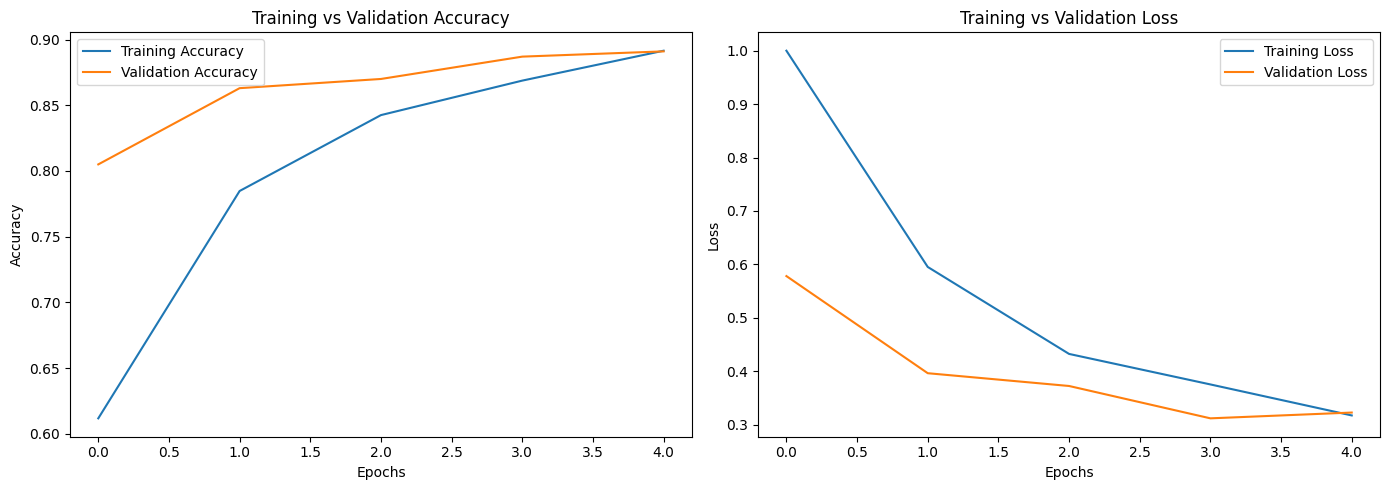

In [ ]:
# PLOT TRAINING AND VALIDATION CURVES

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(
    history_finetune.history['accuracy'],
    label='Training Accuracy')
plt.plot(
    history_finetune.history['val_accuracy'],
    label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#loss

plt.subplot(1,2,2)
plt.plot(
    history_finetune.history['loss'],
    label='Training Loss')
plt.plot(
    history_finetune.history['val_loss'],
    label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# EVALUATE VGG16

loss, accuracy = vgg16_model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.8060 - loss: 0.5660
Validation Loss: 0.5660
Validation Accuracy: 0.8060


In [ ]:
# GENERATE PREDICTIONS

y_pred = vgg16_model.predict(val_generator)
y_pred = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 236ms/step


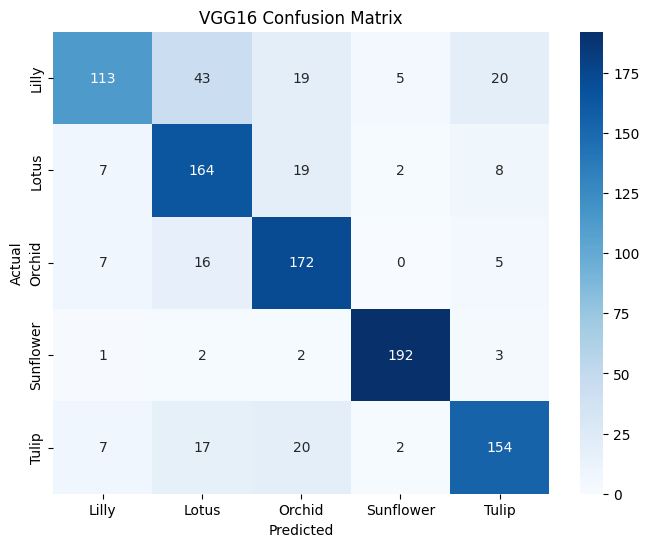

In [ ]:
# CONFUSION MATRIX

cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("VGG16 Confusion Matrix")
plt.show()


In [ ]:
#CLASSIFICATION REPORT

print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

       Lilly       0.84      0.56      0.67       200
       Lotus       0.68      0.82      0.74       200
      Orchid       0.74      0.86      0.80       200
   Sunflower       0.96      0.96      0.96       200
       Tulip       0.81      0.77      0.79       200

    accuracy                           0.80      1000
   macro avg       0.80      0.79      0.79      1000
weighted avg       0.80      0.80      0.79      1000



In [ ]:
#SAVE VGG16 MODEL

mobilenet_model.save('Flower_VGG16_model.keras')
print("VGG16 Model Saved Successfully")

VGG16 Model Saved Successfully
